In [23]:
import pickle
import sys

sys.path.append("../../")
from data_processor.create_graph_data_library import (
    GraphDataLibrary,
    CompanyGraphData,
    RiskOverlayData,
    RiskDataWithEmbedding,
    RiskDataWithOutEmbedding,
    EdgeData,
    EdgeDataNoEmbedding,
)

graph_data_library_path = "../../data/graph/graph_data_library.pkl"
graph_data_library: GraphDataLibrary = pickle.load(open(graph_data_library_path, "rb"))

In [ ]:
import numpy as np


def match_spreadness(set_A, set_B):
    """
    Transforms set_B to have the same mean and standard deviation as set_A.

    Args:
        set_A (list or np.array): The reference dataset.
        set_B (list or np.array): The dataset to be transformed.

    Returns:
        np.array: The transformed set_B.
    """
    # Convert lists to NumPy arrays for efficient calculations
    set_A = np.array(set_A)
    set_B = np.array(set_B)

    # 1. Calculate the mean and standard deviation of set_A (the target)
    mean_A = np.mean(set_A)
    std_A = np.std(set_A)

    # 2. Calculate the mean and standard deviation of set_B (the source)
    mean_B = np.mean(set_B)
    std_B = np.std(set_B)

    # Handle the edge case where std_B is zero to prevent division by zero
    if std_B == 0:
        if std_A == 0:
            return np.full_like(set_B, mean_A)
        else:
            raise ValueError("set_B has zero standard deviation and cannot be scaled.")

    # 3. Standardize set_B (Z-score normalization)
    # This transforms set_B to have a mean of 0 and std_dev of 1
    standardized_B = (set_B - mean_B) / std_B

    # 4. Scale and shift the standardized data to match set_A's spread and center
    transformed_B = standardized_B * std_A + mean_A

    return transformed_B


# Example usage:
set_A = [1.0, 2.0, 3.0, 4.0, 5.0]
set_B = [10.0, 11.0, 12.0]

transformed_B = match_spreadness(set_A, set_B)

print("Original set_A:", set_A)
print("Original set_B:", set_B)
print("Transformed set_B:", transformed_B)

print("\nStatistical comparison:")
print("Mean of A:", np.mean(set_A))
print("Std Dev of A:", np.std(set_A))
print("Mean of Transformed B:", np.mean(transformed_B))
print("Std Dev of Transformed B:", np.std(transformed_B))

Original set_A: [1.0, 2.0, 3.0, 4.0, 5.0]
Original set_B: [10.0, 11.0, 12.0]
Transformed set_B: [1.26794919 3.         4.73205081]

Statistical comparison:
Mean of A: 3.0
Std Dev of A: 1.4142135623730951
Mean of Transformed B: 3.0
Std Dev of Transformed B: 1.414213562373095


In [25]:
import pandas as pd

pcg_graph_id = "PCG|embedding_risk_desc_catalog|oneway_run"
pcg_graph_data: CompanyGraphData = graph_data_library.company_graph_datas[pcg_graph_id]
sample_pcg_edge_data: EdgeData = pcg_graph_data.edges[0]
sample_pcg_edge_data_dict = sample_pcg_edge_data.model_dump()
# loop every edge data
df_row_list = []
for edge_data in pcg_graph_data.edges:
    edge_data_dict = edge_data.model_dump()
    # display(edge_data_dict)
    risk_a_label = edge_data_dict["risk_a_data"]["label"]
    risk_a_catagory = edge_data_dict["risk_a_data"]["risk_cat"]
    risk_b_label = edge_data_dict["risk_b_data"]["label"]
    risk_b_catagory = edge_data_dict["risk_b_data"]["risk_cat"]
    distance = edge_data_dict["distance"]
    cosine_similarity = edge_data_dict["cosine_similarity"]
    row_data = {
        "risk_a_label": risk_a_label,
        "risk_a_catagory": risk_a_catagory,
        "risk_b_label": risk_b_label,
        "risk_b_catagory": risk_b_catagory,
        "distance": distance,
        "cosine_similarity": cosine_similarity,
    }
    df_row_list.append(row_data)
df = pd.DataFrame(df_row_list)
df.head()

,risk_a_label,risk_a_catagory,risk_b_label,risk_b_catagory,distance,cosine_similarity
0,Debtor credit risk (External party),Credit Risk,Debtor credit risk (Internal party),Credit Risk,0.040104,0.919792
1,Product damage during delivery,Operational Risk,Product loss during delivery,Operational Risk,0.067838,0.864324
2,Business interruption from flood,Operational Risk,Business interruption from natural disasters,Operational Risk,0.074032,0.851936
3,Vehicles assets loss,Operational Risk,Vehicles failure and damage,Operational Risk,0.076346,0.847307
4,Product loss during delivery,Operational Risk,Unable to deliver product,Operational Risk,0.077472,0.845056


In [26]:
edge_data_dict["risk_a_data"]

{'id': 'risk_PCG_20250513_34',
 'label': 'Non-compliance with laws regarding migrant workers',
 'risk': 'Non-compliance with laws regarding migrant workers',
 'risk_id': 'risk_PCG_20250513_34',
 'risk_cat': 'Operational Risk',
 'risk_desc': ['เนื่องจากบริษัทฯ มีการจ้างแรงงานข้ามชาติ จึงจำเป็นต้องดำเนินการอย่างถูกต้องและรัดกุม'],
 'cluster_id': -1,
 'risk_score': 3,
 'risk_impact': 3,
 'risk_likelihood': 1,
 'risk_level': 1,
 'process': ['Human Resources: ดำเนินการตามนโยบายการจ้างแรงงานข้ามชาติ ของบริษัท'],
 'rootcause': ['(system) inefficient processes, or inadequate controls and preventive mechanisms: การจ้างแรงงานข้ามชาติ ควรกำหนดนโยบายและวิธีการปฏิบัติให้ชัดเจน เพื่อให้เป็นไปตามกฎหมายที่กำหนดไว้'],
 'process_summary': "Human Resources implements the company's migrant worker employment policies.",
 'rootcause_summary': 'Hiring migrant workers requires clear policies and procedures to comply with applicable laws.',
 'risk_desc_summary': 'The company employs migrant workers and must op

In [27]:
df = df.sort_values(by="cosine_similarity", ascending=False).reset_index(drop=True)
df["cosine_category"] = "rest"
# print cosine_similarity at 150 value
print(df.loc[149, "cosine_similarity"])
df.loc[:149, "cosine_category"] = "top 150"

0.6028376245663415


<Axes: xlabel='distance', ylabel='Count'>

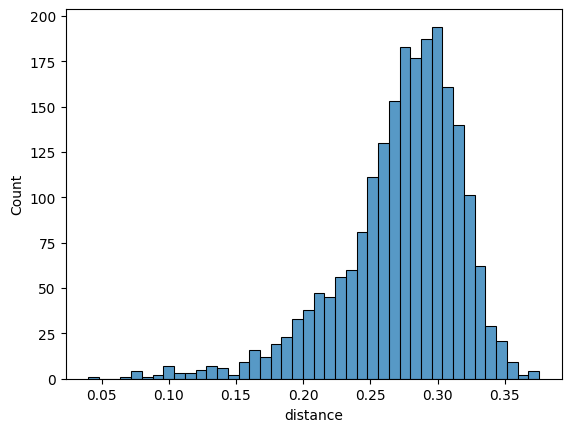

In [28]:
import pandas as pd
import seaborn as sns

# from df plot histogram of column distance and cosine_similarity with seaborn
sns.histplot(df, x="distance")

<Axes: xlabel='cosine_similarity', ylabel='Count'>

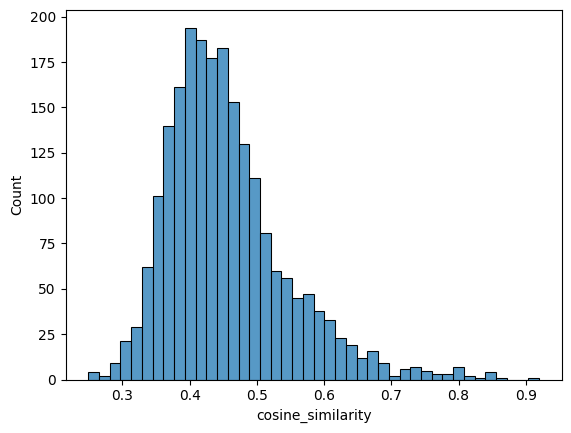

In [29]:
sns.histplot(df, x="cosine_similarity")  # set min to 0 for x

In [30]:
data = df["cosine_similarity"].tolist()
len(data)

2145

In [31]:
import numpy as np


def calculate_plus_n_sigma(data, n):

    # Calculate the mean of the data
    mean = np.mean(data)

    # Calculate the standard deviation of the data
    std_dev = np.std(data)

    # Calculate and return the value of mean + 2 * std_dev
    plus_n_sigma_value = mean + n * std_dev
    return plus_n_sigma_value


plus_2_sigma_value_main_data = calculate_plus_n_sigma(data, 3)
print(np.mean(data))
print(min(data), max(data))
print(plus_2_sigma_value_main_data)


def find_n_from_plus_n_sigma(data, plus_n_sigma_value):
    """
    Calculates the value of 'n' from the plus_n_sigma_value.

    Args:
        data (list or array-like): The dataset.
        plus_n_sigma_value (float): The value representing mean + n * std_dev.

    Returns:
        float: The value of 'n'.
    """
    # Calculate the mean and standard deviation from the data
    mean = np.mean(data)
    std_dev = np.std(data)

    # Avoid division by zero
    if std_dev == 0:
        return None  # Or handle this edge case as appropriate

    # Rearrange the formula: plus_n_sigma_value = mean + n * std_dev
    # to solve for n: n = (plus_n_sigma_value - mean) / std_dev
    n = (plus_n_sigma_value - mean) / std_dev
    return n


find_n_from_plus_n_sigma(data, plus_2_sigma_value_main_data)

0.45484097341054325
0.24900767887993797 0.9197920905839229
0.7260772788853023


np.float64(2.9999999999999996)

<Axes: xlabel='cosine_similarity', ylabel='Count'>

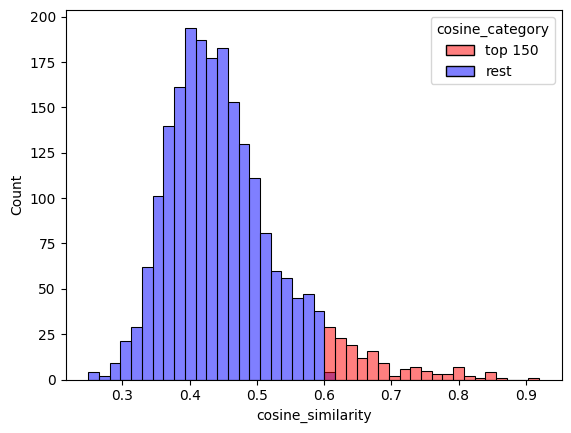

In [32]:
# highlight top value in 150
color_palette = {"top 150": "red", "rest": "blue"}
sns.histplot(
    df, x="cosine_similarity", hue="cosine_category", palette=color_palette
)  # set min to 0 for x

In [33]:
# from cosine_similarity get sigma from it
import numpy as np


def get_sigma_from_cosine_similarity(cosine_similarity: float) -> float:
    return 1 / (1 + np.exp(-cosine_similarity))


get_sigma_from_cosine_similarity(0.5)

np.float64(0.6224593312018546)

In [34]:
risk_label_list = df["risk_a_label"].unique()
risk_label_list

array(['Debtor credit risk (External party)',
       'Product damage during delivery',
       'Business interruption from flood', 'Vehicles assets loss',
       'Product loss during delivery', 'Delayed product delivery',
       'Poor product quality', 'Product-related dissatisfaction',
       'Business interruption from fire hazards', 'Inventory damage',
       'Poor service quality', 'Expired inventory',
       'Overstocking inventory',
       'Business interruption from labor dispute',
       'Unable to deliver product',
       'Business interruption from natural disasters',
       'Industrial pollution', 'Intense market competition',
       'Machinery / equipment failure and damage',
       'Service-related dissatisfaction', 'Machinery / equipment loss',
       'Poor supply quality',
       'Facility infrastructure failure and damage', 'Inventory loss',
       'Decision-making errors', 'Hazardous material handling',
       'Operational inefficiency', 'Obsolete inventory',
       'Ne

In [35]:
print(df["risk_a_catagory"].unique())
risk_label_list = df[df["risk_a_catagory"] == "Strategic Risk"]["risk_a_label"].unique()
risk_label_list

['Credit Risk' 'Operational Risk' 'Strategic Risk' 'Market Risk']


array(['Industrial pollution', 'Intense market competition',
       'New competitor into the market',
       'Hazardous chemicals and small particles',
       'Government policy change', 'Negative media coverage',
       'Global warming', 'Protest', 'Product substitute',
       'Infectious disease (Animal)', 'Raising the minimum wage',
       'Water pollution'], dtype=object)

In [36]:
set_1 = ["Negative media coverage"]
set_2 = [
    "Software Failure",
    "Risk caused by Phishing/Spear Phishing",
    "Risk caused by Cyber Supply Chain Attack",
]
set_3 = [
    "Industrial pollution",
    "Intense market competition",
    "New competitor into the market",
    "Hazardous chemicals and small particles",
    "Government policy change",
    "Negative media coverage",
    "Global warming",
    "Protest",
    "Product substitute",
    "Infectious disease (Animal)",
    "Raising the minimum wage",
    "Water pollution",
]
selected_risk_label_list = set_3
top_n = 132

In [37]:
data_at_top_n = df["cosine_similarity"].iloc[top_n - 1]
print(data_at_top_n)
n_sigma_value = find_n_from_plus_n_sigma(data, data_at_top_n)
print(n_sigma_value)

0.6122831675255658
1.7413840728966195


In [38]:
def get_selected_risk_label_df(
    df: pd.DataFrame, risk_label_list: list[str]
) -> pd.DataFrame:
    df = df.copy()
    # select rows where risk_a_label or risk_b_label is in risk_label_list and set column selected_risk_label to 1

    df["selected_risk_label"] = 1
    # set column selected_risk_label to 0 for rows where risk_a_label or risk_b_label is not in risk_label_list
    df.loc[
        ~df["risk_a_label"].isin(risk_label_list)
        & ~df["risk_b_label"].isin(risk_label_list),
        "selected_risk_label",
    ] = 0

    return df


selected_risk_label_df = get_selected_risk_label_df(df, selected_risk_label_list)
print(selected_risk_label_df.shape)
selected_risk_label_df.head()

(2145, 8)


,risk_a_label,risk_a_catagory,risk_b_label,risk_b_catagory,distance,cosine_similarity,cosine_category,selected_risk_label
0,Debtor credit risk (External party),Credit Risk,Debtor credit risk (Internal party),Credit Risk,0.040104,0.919792,top 150,0
1,Product damage during delivery,Operational Risk,Product loss during delivery,Operational Risk,0.067838,0.864324,top 150,0
2,Business interruption from flood,Operational Risk,Business interruption from natural disasters,Operational Risk,0.074032,0.851936,top 150,0
3,Vehicles assets loss,Operational Risk,Vehicles failure and damage,Operational Risk,0.076346,0.847307,top 150,0
4,Product loss during delivery,Operational Risk,Unable to deliver product,Operational Risk,0.077472,0.845056,top 150,0


In [39]:
sum(selected_risk_label_df["selected_risk_label"])

714

In [40]:
data = selected_risk_label_df[selected_risk_label_df["selected_risk_label"] == 1][
    "cosine_similarity"
].tolist()
data_at_sigma_selected_risk = calculate_plus_n_sigma(data, n_sigma_value)
data_at_sigma_selected_risk

np.float64(0.5235660095207377)

<Axes: xlabel='cosine_similarity', ylabel='Count'>

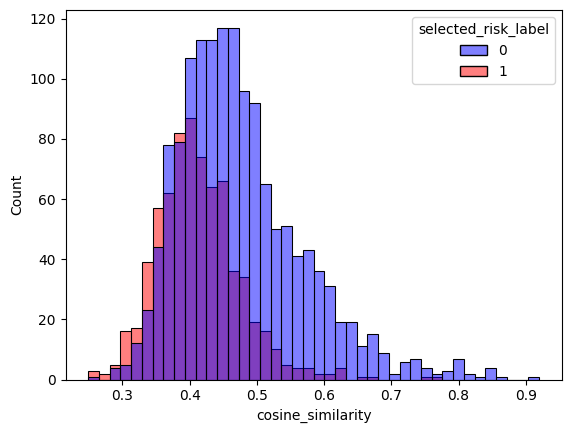

In [41]:
# highlight top value in 150
color_palette = {1: "red", 0: "blue"}
sns.histplot(
    selected_risk_label_df,
    x="cosine_similarity",
    hue="selected_risk_label",
    palette=color_palette,
)  # set min to 0 for x

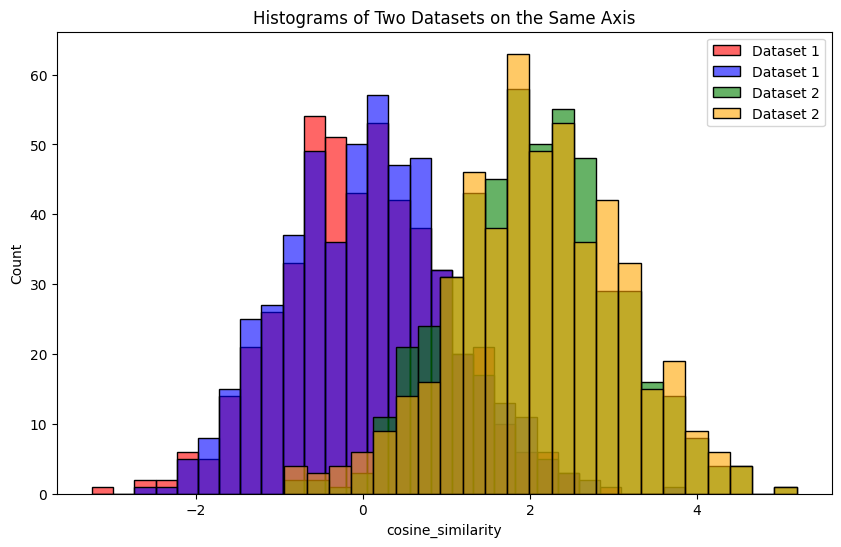

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Sample Data (replace with your actual data)
np.random.seed(42)
data1 = np.random.normal(loc=0, scale=1, size=1000)
data2 = np.random.normal(loc=2, scale=1, size=1000)

df1 = pd.DataFrame(
    {"cosine_similarity": data1, "selected_risk_label": np.random.randint(0, 2, 1000)}
)
df2 = pd.DataFrame(
    {"cosine_similarity": data2, "selected_risk_label": np.random.randint(0, 2, 1000)}
)

# Create a figure and a single subplot
fig, ax = plt.subplots(figsize=(10, 6))

# Define the color palette for the first plot
color_palette_1 = {1: "red", 0: "blue"}

# Plot the first histplot on the created axis
sns.histplot(
    df1,
    x="cosine_similarity",
    hue="selected_risk_label",
    palette=color_palette_1,
    ax=ax,  # Use the same axis for the first plot
    alpha=0.6,
    label="Dataset 1",
)

# Define a different color palette for the second plot, for clarity
color_palette_2 = {1: "green", 0: "orange"}

# Plot the second histplot on the SAME axis
sns.histplot(
    df2,
    x="cosine_similarity",
    hue="selected_risk_label",
    palette=color_palette_2,
    ax=ax,  # Use the SAME axis for the second plot
    alpha=0.6,
    label="Dataset 2",
)

# Add a title and legend
ax.set_title("Histograms of Two Datasets on the Same Axis")
ax.legend()

# Display the plot
plt.show()

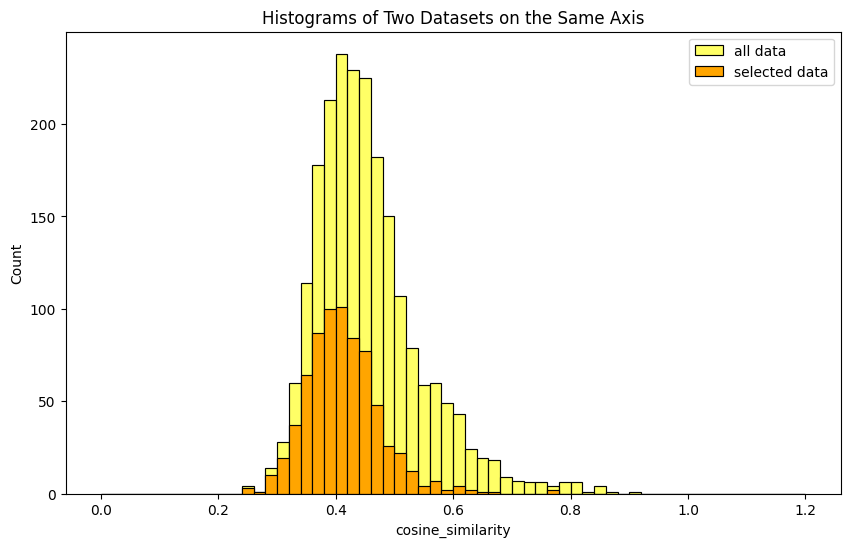

In [ ]:
selected_risk_label_df_only_1 = selected_risk_label_df[
    selected_risk_label_df["selected_risk_label"] == 1
]
selected_risk_label_df_only_1.head()
fig, ax = plt.subplots(figsize=(10, 6))

bins = 60
bin_range = (0, 1.2)
# Plot the first histplot on the created axis

# Define a different color palette for the second plot, for clarity

# Plot the second histplot on the SAME axis
sns.histplot(
    selected_risk_label_df,
    x="cosine_similarity",
    ax=ax,  # Use the SAME axis for the second plot
    alpha=0.6,
    label="all data",
    bins=bins,  # Set the number of bins
    binrange=bin_range,  # Set the range of the bins
    color="yellow",
)
sns.histplot(
    selected_risk_label_df_only_1,
    x="cosine_similarity",
    ax=ax,  # Use the same axis for the first plot
    alpha=1.0,
    label="selected data",
    bins=bins,  # Set the number of bins
    binrange=bin_range,  # Set the range of the bins
    color="orange",
)


# Add a title and legend
ax.set_title("Histograms of Two Datasets on the Same Axis")
ax.legend()

# Display the plot
plt.show()

In [62]:
diff_graph_value = data_at_top_n - data_at_sigma_selected_risk

print(diff_graph_value)

0.08871715800482805


/tmp/ipykernel_1075173/1511765996.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_risk_label_df_only_1_shifted["cosine_similarity"] = (


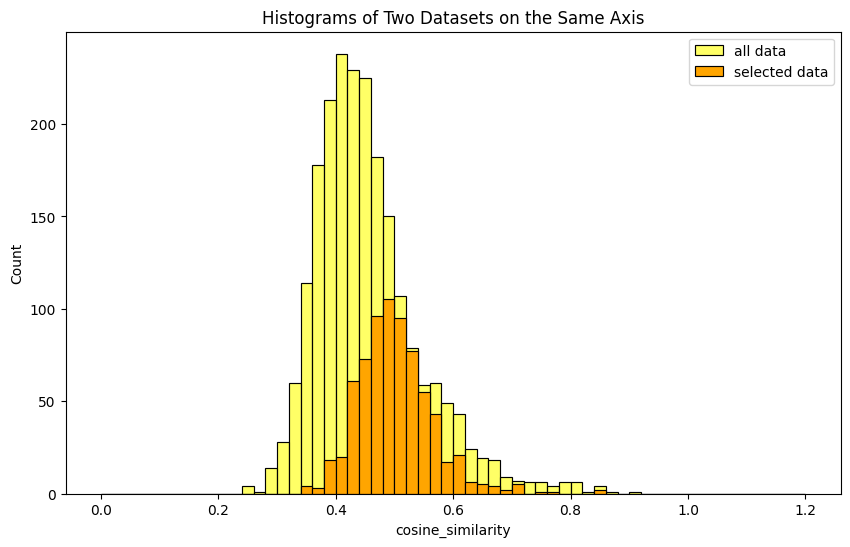

In [63]:
selected_risk_label_df_only_1_shifted = selected_risk_label_df[
    selected_risk_label_df["selected_risk_label"] == 1
]
# add diff_graph_value to cosine_similarity
selected_risk_label_df_only_1_shifted["cosine_similarity"] = (
    selected_risk_label_df_only_1_shifted["cosine_similarity"] + diff_graph_value
)
selected_risk_label_df_only_1_shifted.head()
fig, ax = plt.subplots(figsize=(10, 6))

bins = 60
bin_range = (0, 1.2)
# Plot the first histplot on the created axis

# Define a different color palette for the second plot, for clarity

# Plot the second histplot on the SAME axis
sns.histplot(
    selected_risk_label_df,
    x="cosine_similarity",
    ax=ax,  # Use the SAME axis for the second plot
    alpha=0.6,
    label="all data",
    bins=bins,  # Set the number of bins
    binrange=bin_range,  # Set the range of the bins
    color="yellow",
)
sns.histplot(
    selected_risk_label_df_only_1_shifted,
    x="cosine_similarity",
    ax=ax,  # Use the same axis for the first plot
    alpha=1.0,
    label="selected data",
    bins=bins,  # Set the number of bins
    binrange=bin_range,  # Set the range of the bins
    color="orange",
)


# Add a title and legend
ax.set_title("Histograms of Two Datasets on the Same Axis")
ax.legend()

# Display the plot
plt.show()

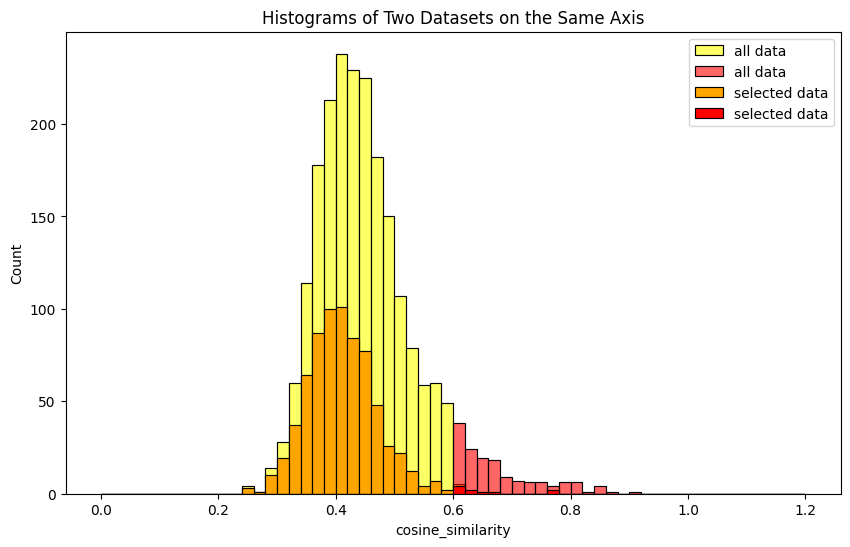

In [64]:
selected_risk_label_df_only_1 = selected_risk_label_df[
    selected_risk_label_df["selected_risk_label"] == 1
]
selected_risk_label_df_only_1.head()
fig, ax = plt.subplots(figsize=(10, 6))

bins = 60
bin_range = (0, 1.2)
# Plot the first histplot on the created axis

# Define a different color palette for the second plot, for clarity

color_palette = {"top 150": "red", "rest": "yellow"}

# Plot the second histplot on the SAME axis
sns.histplot(
    selected_risk_label_df,
    x="cosine_similarity",
    ax=ax,  # Use the SAME axis for the second plot
    alpha=0.6,
    label="all data",
    bins=bins,  # Set the number of bins
    binrange=bin_range,  # Set the range of the bins
    hue="cosine_category",
    palette=color_palette,
)
color_palette = {"top 150": "red", "rest": "orange"}

sns.histplot(
    selected_risk_label_df_only_1,
    x="cosine_similarity",
    ax=ax,  # Use the same axis for the first plot
    alpha=1.0,
    label="selected data",
    bins=bins,  # Set the number of bins
    binrange=bin_range,  # Set the range of the bins
    hue="cosine_category",
    palette=color_palette,
)


# Add a title and legend
ax.set_title("Histograms of Two Datasets on the Same Axis")
ax.legend()

# Display the plot
plt.show()

In [68]:
data_at_top_n

np.float64(0.6122831675255658)

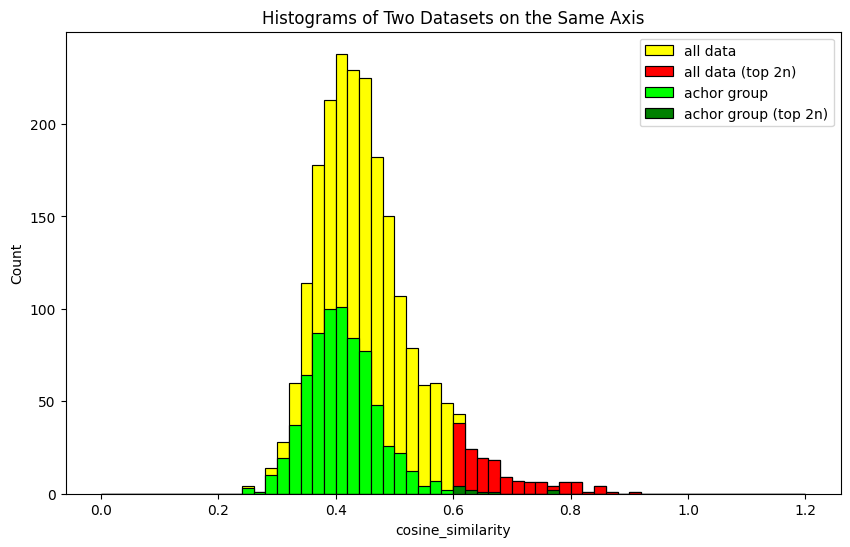

In [85]:
selected_risk_label_df_only_1 = selected_risk_label_df[
    selected_risk_label_df["selected_risk_label"] == 1
]
# for data cosine_similarity > data_at_sigma_selected_risk then set cosine_category to top 150
selected_risk_label_df_only_1.loc[
    selected_risk_label_df_only_1["cosine_similarity"] > data_at_top_n,
    "cosine_category",
] = "top 150"
selected_risk_label_df_only_1.head()
fig, ax = plt.subplots(figsize=(10, 6))

bins = 60
bin_range = (0, 1.2)
# Plot the first histplot on the created axis

# Define a different color palette for the second plot, for clarity

color_palette = {"rest": "yellow"}

# Plot the second histplot on the SAME axis
sns.histplot(
    selected_risk_label_df,
    x="cosine_similarity",
    ax=ax,  # Use the SAME axis for the second plot
    alpha=1.0,
    label="all data",
    bins=bins,  # Set the number of bins
    binrange=bin_range,  # Set the range of the bins
    color="yellow",
)

sns.histplot(
    selected_risk_label_df[selected_risk_label_df["cosine_category"] == "top 150"],
    x="cosine_similarity",
    ax=ax,  # Use the same axis for the first plot
    alpha=1.0,
    label="all data (top 2n)",
    bins=bins,  # Set the number of bins
    binrange=bin_range,  # Set the range of the bins
    color="red",
)


sns.histplot(
    selected_risk_label_df_only_1[
        selected_risk_label_df_only_1["cosine_category"] == "rest"
    ],
    x="cosine_similarity",
    ax=ax,  # Use the same axis for the first plot
    alpha=1.0,
    label="achor group",
    bins=bins,  # Set the number of bins
    binrange=bin_range,  # Set the range of the bins
    color="lime",
)

sns.histplot(
    selected_risk_label_df_only_1[
        selected_risk_label_df_only_1["cosine_category"] == "top 150"
    ],
    x="cosine_similarity",
    ax=ax,  # Use the same axis for the first plot
    alpha=1.0,
    label="achor group (top 2n)",
    bins=bins,  # Set the number of bins
    binrange=bin_range,  # Set the range of the bins
    color="green",
)

# Add a title and legend
ax.set_title("Histograms of Two Datasets on the Same Axis")
ax.legend()

# Display the plot
plt.show()

/tmp/ipykernel_1075173/1945588745.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_risk_label_df_only_1_shifted["cosine_similarity"] = (


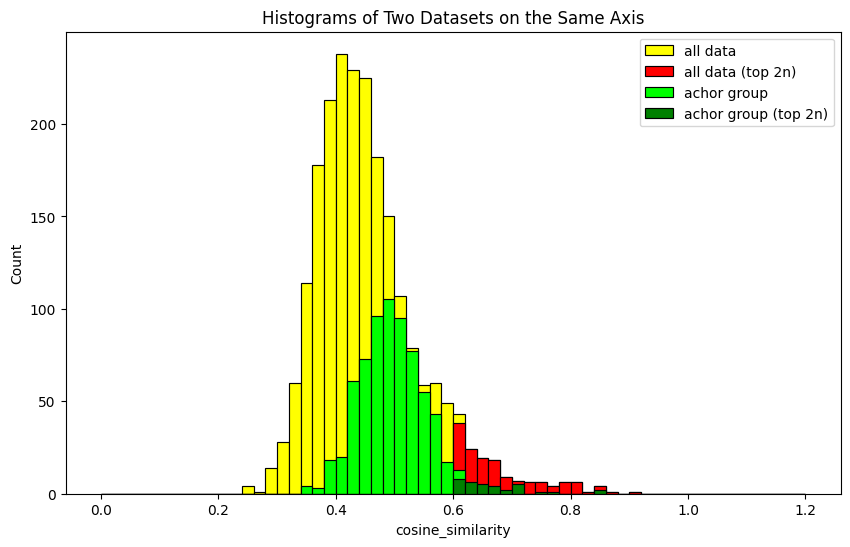

In [86]:
selected_risk_label_df_only_1_shifted = selected_risk_label_df[
    selected_risk_label_df["selected_risk_label"] == 1
]
# add diff_graph_value to cosine_similarity
selected_risk_label_df_only_1_shifted["cosine_similarity"] = (
    selected_risk_label_df_only_1_shifted["cosine_similarity"] + diff_graph_value
)
# for data cosine_similarity > data_at_sigma_selected_risk then set cosine_category to top 150
selected_risk_label_df_only_1_shifted.loc[
    selected_risk_label_df_only_1_shifted["cosine_similarity"] > data_at_top_n,
    "cosine_category",
] = "top 150"
selected_risk_label_df_only_1_shifted.head()
fig, ax = plt.subplots(figsize=(10, 6))

bins = 60
bin_range = (0, 1.2)
# Plot the first histplot on the created axis

# Define a different color palette for the second plot, for clarity

color_palette = {"rest": "yellow"}

# Plot the second histplot on the SAME axis
sns.histplot(
    selected_risk_label_df,
    x="cosine_similarity",
    ax=ax,  # Use the SAME axis for the second plot
    alpha=1.0,
    label="all data",
    bins=bins,  # Set the number of bins
    binrange=bin_range,  # Set the range of the bins
    color="yellow",
)

sns.histplot(
    selected_risk_label_df[selected_risk_label_df["cosine_category"] == "top 150"],
    x="cosine_similarity",
    ax=ax,  # Use the same axis for the first plot
    alpha=1.0,
    label="all data (top 2n)",
    bins=bins,  # Set the number of bins
    binrange=bin_range,  # Set the range of the bins
    color="red",
)


sns.histplot(
    selected_risk_label_df_only_1_shifted[
        selected_risk_label_df_only_1_shifted["cosine_category"] == "rest"
    ],
    x="cosine_similarity",
    ax=ax,  # Use the same axis for the first plot
    alpha=1.0,
    label="achor group",
    bins=bins,  # Set the number of bins
    binrange=bin_range,  # Set the range of the bins
    color="lime",
)

sns.histplot(
    selected_risk_label_df_only_1_shifted[
        selected_risk_label_df_only_1_shifted["cosine_category"] == "top 150"
    ],
    x="cosine_similarity",
    ax=ax,  # Use the same axis for the first plot
    alpha=1.0,
    label="achor group (top 2n)",
    bins=bins,  # Set the number of bins
    binrange=bin_range,  # Set the range of the bins
    color="green",
)

# Add a title and legend
ax.set_title("Histograms of Two Datasets on the Same Axis")
ax.legend()

# Display the plot
plt.show()

In [ ]:
selected_risk_label_df_only_1 = selected_risk_label_df[
    selected_risk_label_df["selected_risk_label"] == 1
]
selected_risk_label_df_only_1.head()
fig, ax = plt.subplots(figsize=(10, 6))

bins = 60
bin_range = (0, 1.2)
# Plot the first histplot on the created axis

# Define a different color palette for the second plot, for clarity

color_palette = {"top 150": "red", "rest": "yellow"}

# Plot the second histplot on the SAME axis
sns.histplot(
    selected_risk_label_df,
    x="cosine_similarity",
    ax=ax,  # Use the SAME axis for the second plot
    alpha=0.6,
    label="all data",
    bins=bins,  # Set the number of bins
    binrange=bin_range,  # Set the range of the bins
    hue="cosine_category",
    palette=color_palette,
)
color_palette = {"top 150": "red", "rest": "orange"}

sns.histplot(
    selected_risk_label_df_only_1,
    x="cosine_similarity",
    ax=ax,  # Use the same axis for the first plot
    alpha=1.0,
    label="selected data",
    bins=bins,  # Set the number of bins
    binrange=bin_range,  # Set the range of the bins
    hue="cosine_category",
    palette=color_palette,
)


# Add a title and legend
ax.set_title("Histograms of Two Datasets on the Same Axis")
ax.legend()

# Display the plot
plt.show()

0.08871715800482805


33


<Axes: xlabel='cosine_similarity', ylabel='Count'>

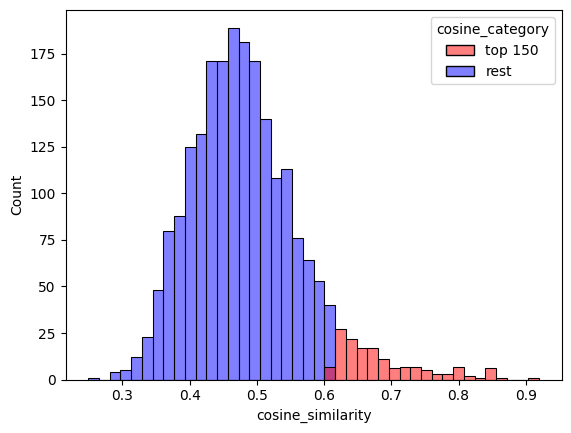

In [43]:
adjusted_selected_risk_label_df = selected_risk_label_df.copy()
# for column cosine_similarity,add diff_graph_value for row that selected_risk_label is 1
# loop every row in adjusted_selected_risk_label_df
for index, row in adjusted_selected_risk_label_df.iterrows():
    if row["selected_risk_label"] == 1:
        adjusted_selected_risk_label_df.at[index, "cosine_similarity"] = (
            row["cosine_similarity"] + diff_graph_value
        )
# redo the 150 top value
adjusted_selected_risk_label_df = adjusted_selected_risk_label_df.sort_values(
    by="cosine_similarity", ascending=False
).reset_index(drop=True)
adjusted_selected_risk_label_df.loc[:149, "cosine_category"] = "top 150"
adjusted_selected_risk_label_df.loc[150:, "cosine_category"] = "rest"

# print number of row that selected_risk_label is 1 and cosine_category is top 150
print(
    adjusted_selected_risk_label_df[
        (adjusted_selected_risk_label_df["selected_risk_label"] == 1)
        & (adjusted_selected_risk_label_df["cosine_category"] == "top 150")
    ].shape[0]
)
# plot histogram of cosine_similarity with top 150 and rest
color_palette = {"top 150": "red", "rest": "blue"}
sns.histplot(
    adjusted_selected_risk_label_df,
    x="cosine_similarity",
    hue="cosine_category",
    palette=color_palette,
)

10


<Axes: xlabel='cosine_similarity', ylabel='Count'>

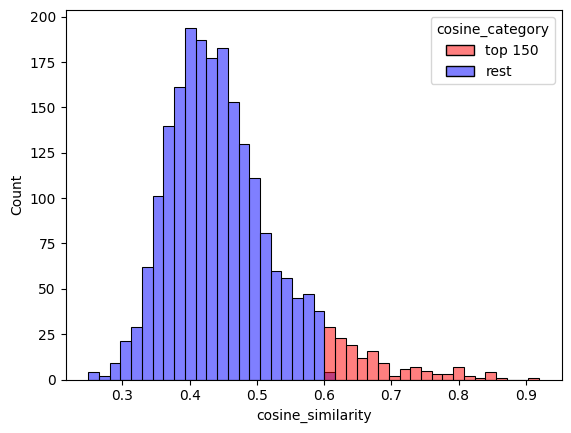

In [44]:
print(
    selected_risk_label_df[
        (selected_risk_label_df["selected_risk_label"] == 1)
        & (selected_risk_label_df["cosine_category"] == "top 150")
    ].shape[0]
)
sns.histplot(
    df,
    x="cosine_similarity",
    hue="cosine_category",
    palette=color_palette,
)

In [45]:
def find_round_indices(data_list, input_value):
    """
    Finds the indices of the closest values above and below an input value
    in a sorted list of floats.

    Args:
        data_list (list): A sorted list of floating-point numbers.
        input_value (float): The value to search for.

    Returns:
        tuple: A tuple containing the "round down" and "round up" indices.
               Returns (None, None) if the list is empty or if no valid
               indices are found.
    """
    if not data_list:
        return (None, None)

    round_down_index = None
    round_up_index = None

    for i, value in enumerate(data_list):
        if value < input_value:
            round_down_index = i
        elif value >= input_value:
            round_up_index = i
            break

    # Handle cases where the input value is outside the list's range.
    if round_down_index is None and round_up_index is not None:
        round_down_index = -1  # Or handle as you see fit.
    elif round_up_index is None and round_down_index is not None:
        round_up_index = len(data_list)  # Or handle as you see fit.

    return (round_down_index, round_up_index)


# Example usage:
my_data = [1.1, 2.5, 3.8, 5.2, 6.7, 8.1]
my_input = 4.5

down_index, up_index = find_round_indices(my_data, my_input)

print(f"List: {my_data}")
print(f"Input value: {my_input}")
print(
    f"Round down index: {down_index} (value: {my_data[down_index] if down_index is not None else 'N/A'})"
)
print(
    f"Round up index: {up_index} (value: {my_data[up_index] if up_index is not None else 'N/A'})"
)

List: [1.1, 2.5, 3.8, 5.2, 6.7, 8.1]
Input value: 4.5
Round down index: 2 (value: 3.8)
Round up index: 3 (value: 5.2)
